# WORKSHEET - 3

**Department of Computer Science and Engineering**
**2024 CSE BATCH — 23CSE463 : Quantum Computing**

**Name:** Agneay B Nair
**Roll No:** CH.SC.U4CSE24102

**Ex. No:** 2   |   **Date:** 16/07/2026

**Title:** Matrix Representation, Verification, and Simulation of Fundamental Single-Qubit Quantum Gates using PennyLane

**Aim:** To study the fundamentals of the PennyLane quantum computing framework and understand its architecture for designing and executing quantum circuits — creating quantum devices, implementing QNodes, applying basic single-qubit quantum gates, performing quantum measurements, and analyzing the results with PennyLane.

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

dev = qml.device('default.qubit', wires=1)

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

def run_gate(gate_matrix, state, gate_op=None, wires=0):
    """Apply a gate two ways: classical matrix multiplication, and PennyLane simulation."""
    classical = gate_matrix @ state
    @qml.qnode(dev)
    def circuit():
        qml.StatePrep(state, wires=wires)
        if gate_op is not None:
            gate_op(wires=wires)
        return qml.state()
    quantum = circuit()
    return classical, quantum

print("Setup complete: PennyLane version", qml.__version__)

Setup complete: PennyLane version 0.45.1


### Program 1
Implement the Identity gate matrix and verify its operation on the computational basis states |0⟩ and |1⟩ using matrix multiplication and PennyLane.

In [2]:
I = np.array([[1, 0], [0, 1]], dtype=complex)
print("Identity matrix I =\n", I)
for label, state in [("|0>", ket0), ("|1>", ket1)]:
    c, q = run_gate(I, state, qml.Identity)
    print(f"I . {label} (matrix)    = {c}")
    print(f"I . {label} (PennyLane) = {q}")
print("\nObservation: The Identity gate leaves both basis states completely unchanged.")

Identity matrix I =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
I . |0> (matrix)    = [1.+0.j 0.+0.j]
I . |0> (PennyLane) = [1.+0.j 0.+0.j]
I . |1> (matrix)    = [0.+0.j 1.+0.j]
I . |1> (PennyLane) = [0.+0.j 1.+0.j]

Observation: The Identity gate leaves both basis states completely unchanged.


### Program 2
Implement the Pauli-X Gate Matrix and Verify Its Transformation.

In [3]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
print("Pauli-X matrix X =\n", X)
for label, state in [("|0>", ket0), ("|1>", ket1)]:
    c, q = run_gate(X, state, qml.PauliX)
    print(f"X . {label} (matrix)    = {c}")
    print(f"X . {label} (PennyLane) = {q}")
print("\nObservation: Pauli-X acts as a classical bit-flip (NOT) gate: |0> <-> |1>.")

Pauli-X matrix X =
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
X . |0> (matrix)    = [0.+0.j 1.+0.j]
X . |0> (PennyLane) = [0.+0.j 1.+0.j]
X . |1> (matrix)    = [1.+0.j 0.+0.j]
X . |1> (PennyLane) = [1.+0.j 0.+0.j]

Observation: Pauli-X acts as a classical bit-flip (NOT) gate: |0> <-> |1>.


### Program 3
Implement the Pauli-Y Gate Matrix and Analyze the Phase Transformation.

In [4]:
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
print("Pauli-Y matrix Y =\n", Y)
for label, state in [("|0>", ket0), ("|1>", ket1)]:
    c, q = run_gate(Y, state, qml.PauliY)
    print(f"Y . {label} (matrix)    = {c}")
    print(f"Y . {label} (PennyLane) = {q}")
print("\nObservation: Pauli-Y flips the bit AND introduces an imaginary phase (+i or -i) - a combined bit-flip and phase-flip.")

Pauli-Y matrix Y =
 [[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]
Y . |0> (matrix)    = [0.+0.j 0.+1.j]
Y . |0> (PennyLane) = [0.+0.j 0.+1.j]
Y . |1> (matrix)    = [0.-1.j 0.+0.j]
Y . |1> (PennyLane) = [0.-1.j 0.+0.j]

Observation: Pauli-Y flips the bit AND introduces an imaginary phase (+i or -i) - a combined bit-flip and phase-flip.


### Program 4
Implement the Pauli-Z gate matrix and verify its phase inversion using matrix multiplication and PennyLane.

In [5]:
Z = np.array([[1, 0], [0, -1]], dtype=complex)
print("Pauli-Z matrix Z =\n", Z)
for label, state in [("|0>", ket0), ("|1>", ket1)]:
    c, q = run_gate(Z, state, qml.PauliZ)
    print(f"Z . {label} (matrix)    = {c}")
    print(f"Z . {label} (PennyLane) = {q}")
print("\nObservation: Pauli-Z leaves |0> unchanged and inverts the phase of |1> (multiplies it by -1).")

Pauli-Z matrix Z =
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Z . |0> (matrix)    = [1.+0.j 0.+0.j]
Z . |0> (PennyLane) = [ 1.+0.j -0.+0.j]
Z . |1> (matrix)    = [ 0.+0.j -1.+0.j]
Z . |1> (PennyLane) = [ 0.+0.j -1.+0.j]

Observation: Pauli-Z leaves |0> unchanged and inverts the phase of |1> (multiplies it by -1).


### Program 5
Implement the Phase (S) gate matrix and verify its phase-shift operation on the computational basis states.

In [6]:
S = np.array([[1, 0], [0, 1j]], dtype=complex)
print("Phase (S) matrix S =\n", S)
for label, state in [("|0>", ket0), ("|1>", ket1)]:
    c, q = run_gate(S, state, qml.S)
    print(f"S . {label} (matrix)    = {c}")
    print(f"S . {label} (PennyLane) = {q}")
print("\nObservation: The S gate leaves |0> unchanged and applies a pi/2 phase shift (multiplies by i) to |1>.")

Phase (S) matrix S =
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
S . |0> (matrix)    = [1.+0.j 0.+0.j]
S . |0> (PennyLane) = [1.+0.j 0.+0.j]
S . |1> (matrix)    = [0.+0.j 0.+1.j]
S . |1> (PennyLane) = [0.+0.j 0.+1.j]

Observation: The S gate leaves |0> unchanged and applies a pi/2 phase shift (multiplies by i) to |1>.


### Program 6
Implement the T gate matrix and verify the π/4 phase rotation using matrix multiplication and PennyLane simulation.

In [7]:
T = np.array([[1, 0], [0, np.exp(1j*np.pi/4)]], dtype=complex)
print("T matrix T =\n", T)
print("e^(i*pi/4) =", np.exp(1j*np.pi/4))
for label, state in [("|0>", ket0), ("|1>", ket1)]:
    c, q = run_gate(T, state, qml.T)
    print(f"T . {label} (matrix)    = {c}")
    print(f"T . {label} (PennyLane) = {q}")
print("\nObservation: The T gate leaves |0> unchanged and applies a pi/4 phase rotation to |1>.")

T matrix T =
 [[1.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.70710678+0.70710678j]]
e^(i*pi/4) = (0.7071067811865476+0.7071067811865475j)
T . |0> (matrix)    = [1.+0.j 0.+0.j]
T . |0> (PennyLane) = [1.+0.j 0.+0.j]
T . |1> (matrix)    = [0.        +0.j         0.70710678+0.70710678j]
T . |1> (PennyLane) = [0.        +0.j         0.70710678+0.70710678j]

Observation: The T gate leaves |0> unchanged and applies a pi/4 phase rotation to |1>.


### Program 7
Implement the Hadamard gate matrix and verify the creation of the equal superposition state using analytical calculations and PennyLane simulation.

In [8]:
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
print("Hadamard matrix H =\n", H)
for label, state in [("|0>", ket0), ("|1>", ket1)]:
    c, q = run_gate(H, state, qml.Hadamard)
    print(f"H . {label} (matrix)    = {c}")
    print(f"H . {label} (PennyLane) = {q}")
print("\nObservation: The Hadamard gate creates an equal superposition of |0> and |1>, with a relative minus sign appearing when starting from |1>.")

Hadamard matrix H =
 [[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]
H . |0> (matrix)    = [0.70710678+0.j 0.70710678+0.j]
H . |0> (PennyLane) = [0.70710678+0.j 0.70710678+0.j]
H . |1> (matrix)    = [ 0.70710678+0.j -0.70710678+0.j]
H . |1> (PennyLane) = [ 0.70710678+0.j -0.70710678+0.j]

Observation: The Hadamard gate creates an equal superposition of |0> and |1>, with a relative minus sign appearing when starting from |1>.


### Program 8
Compare the transformations produced by the Identity, Pauli-X, Pauli-Y, Pauli-Z, Phase (S), T, and Hadamard gates on the computational basis state |0⟩.

  Identity . |0> = [1.+0.j 0.+0.j]  (probabilities: [1. 0.])
   Pauli-X . |0> = [0.+0.j 1.+0.j]  (probabilities: [0. 1.])
   Pauli-Y . |0> = [0.+0.j 0.+1.j]  (probabilities: [0. 1.])
   Pauli-Z . |0> = [ 1.+0.j -0.+0.j]  (probabilities: [1. 0.])
 Phase (S) . |0> = [1.+0.j 0.+0.j]  (probabilities: [1. 0.])
         T . |0> = [1.+0.j 0.+0.j]  (probabilities: [1. 0.])
  Hadamard . |0> = [0.70710678+0.j 0.70710678+0.j]  (probabilities: [0.5 0.5])


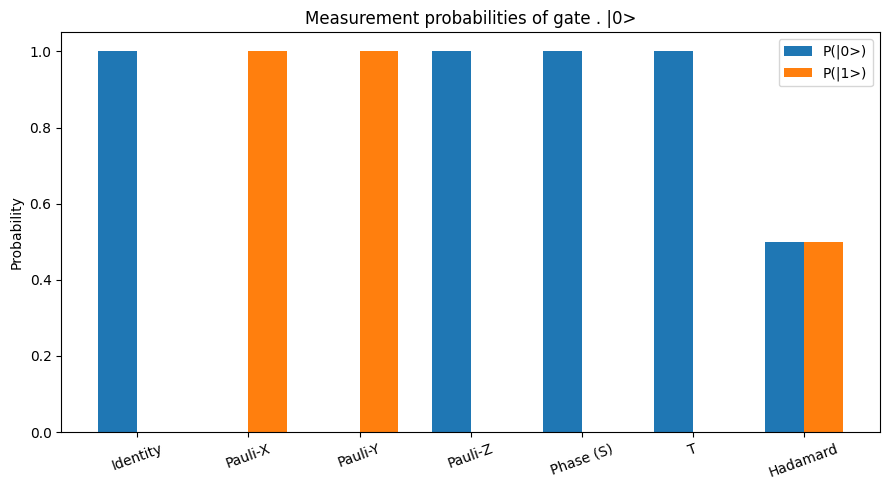


Observation: X and H move population toward/across |1>, while Y, Z, S, T only change the phase relative to |0> (so their probabilities match |0> exactly); H splits the probability equally.


In [9]:
gates_p8 = {
    "Identity": (I, qml.Identity), "Pauli-X": (X, qml.PauliX), "Pauli-Y": (Y, qml.PauliY),
    "Pauli-Z": (Z, qml.PauliZ), "Phase (S)": (S, qml.S), "T": (T, qml.T), "Hadamard": (H, qml.Hadamard),
}
results_p8 = {}
for name, (mat, op) in gates_p8.items():
    c, q = run_gate(mat, ket0, op)
    results_p8[name] = q
    print(f"{name:>10} . |0> = {q}  (probabilities: {np.round(np.abs(q)**2,3)})")

fig, ax = plt.subplots(figsize=(9,5))
names = list(results_p8.keys())
probs0 = [np.abs(results_p8[n][0])**2 for n in names]
probs1 = [np.abs(results_p8[n][1])**2 for n in names]
x = np.arange(len(names)); width = 0.35
ax.bar(x - width/2, probs0, width, label='P(|0>)')
ax.bar(x + width/2, probs1, width, label='P(|1>)')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20)
ax.set_ylabel('Probability'); ax.set_title('Measurement probabilities of gate . |0>')
ax.legend(); plt.tight_layout(); plt.show()

print("\nObservation: X and H move population toward/across |1>, while Y, Z, S, T only change the phase "
      "relative to |0> (so their probabilities match |0> exactly); H splits the probability equally.")

### Program 9
Verify the unitary property of the Pauli-X, Pauli-Y, Pauli-Z, Phase (S), T, and Hadamard matrices by computing U†U.

In [10]:
gates_p9 = {"Pauli-X": X, "Pauli-Y": Y, "Pauli-Z": Z, "Phase (S)": S, "T": T, "Hadamard": H}
for name, U in gates_p9.items():
    product = np.conj(U).T @ U
    is_unitary = np.allclose(product, I)
    print(f"{name:>10}: U-dagger . U =\n{np.round(product,3)}\n  Unitary? {is_unitary}\n")

   Pauli-X: U-dagger . U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
  Unitary? True

   Pauli-Y: U-dagger . U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
  Unitary? True

   Pauli-Z: U-dagger . U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
  Unitary? True

 Phase (S): U-dagger . U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
  Unitary? True

         T: U-dagger . U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.-0.j]]
  Unitary? True

  Hadamard: U-dagger . U =
[[ 1.+0.j -0.+0.j]
 [-0.+0.j  1.+0.j]]
  Unitary? True



### Program 10
Develop a PennyLane program to implement all the fundamental one-qubit quantum gates, compare their matrix representations with simulated quantum state transformations, and visualize the resulting probability distributions.

Gate I: matrix result = [1.+0.j 0.+0.j], PennyLane result = [1.+0.j 0.+0.j], match = True
Gate X: matrix result = [0.+0.j 1.+0.j], PennyLane result = [0.+0.j 1.+0.j], match = True
Gate Y: matrix result = [0.+0.j 0.+1.j], PennyLane result = [0.+0.j 0.+1.j], match = True
Gate Z: matrix result = [1.+0.j 0.+0.j], PennyLane result = [ 1.+0.j -0.+0.j], match = True
Gate S: matrix result = [1.+0.j 0.+0.j], PennyLane result = [1.+0.j 0.+0.j], match = True
Gate T: matrix result = [1.+0.j 0.+0.j], PennyLane result = [1.+0.j 0.+0.j], match = True
Gate H: matrix result = [0.707+0.j 0.707+0.j], PennyLane result = [0.707+0.j 0.707+0.j], match = True


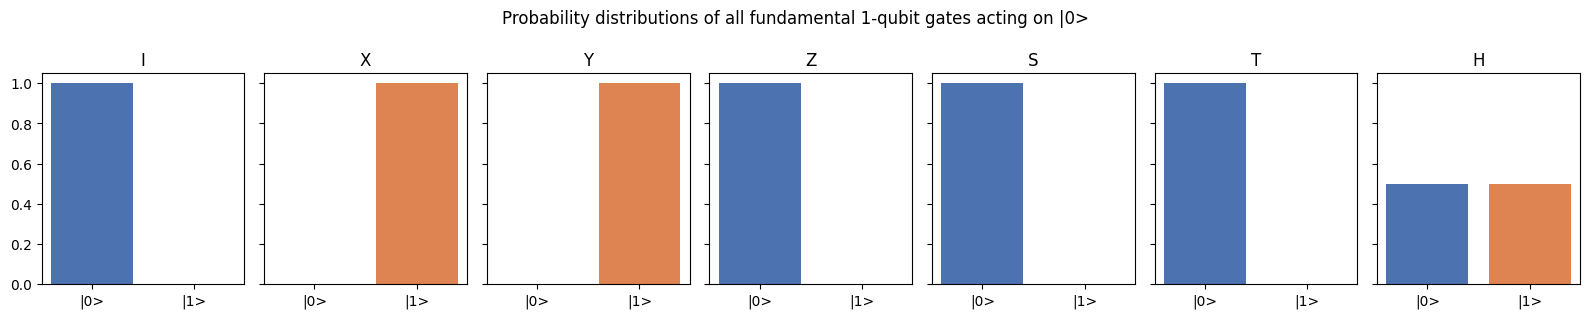


Observation: All matrix-based and PennyLane-simulated results match exactly, confirming correct implementation of every fundamental single-qubit gate.


In [11]:
all_gates = {"I": (I, qml.Identity), "X": (X, qml.PauliX), "Y": (Y, qml.PauliY), "Z": (Z, qml.PauliZ),
             "S": (S, qml.S), "T": (T, qml.T), "H": (H, qml.Hadamard)}
final_states = {}
for name, (mat, op) in all_gates.items():
    c, q = run_gate(mat, ket0, op)
    final_states[name] = q
    match = np.allclose(c, q)
    print(f"Gate {name}: matrix result = {np.round(c,3)}, PennyLane result = {np.round(q,3)}, match = {match}")

fig, axes = plt.subplots(1, len(all_gates), figsize=(16,3.2), sharey=True)
for ax, (name, state) in zip(axes, final_states.items()):
    probs = np.abs(state)**2
    ax.bar(['|0>','|1>'], probs, color=['#4C72B0','#DD8452'])
    ax.set_title(name); ax.set_ylim(0,1.05)
fig.suptitle('Probability distributions of all fundamental 1-qubit gates acting on |0>')
plt.tight_layout(); plt.show()

print("\nObservation: All matrix-based and PennyLane-simulated results match exactly, confirming correct "
      "implementation of every fundamental single-qubit gate.")

## Result

The fundamentals of the PennyLane quantum computing framework were studied and verified. Quantum devices and
QNodes were created, and the Identity, Pauli-X, Pauli-Y, Pauli-Z, Phase (S), T, and Hadamard single-qubit
gates were implemented, applied to the computational basis states, and simulated successfully. The matrix
multiplication results matched the PennyLane simulation results exactly in every program, all gate matrices
were verified to be unitary (U†U = I), and the resulting probability distributions were visualized. Thus, the
implementation of fundamental single-qubit quantum gates using PennyLane was executed and verified
successfully.